In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1,2,6,9'

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
from src.ScoreBasedInferenceModel import ScoreBasedInferenceModel as SBIm
from src.plot_functions import *

import matplotlib.pyplot as plt
import matplotlib.animation
import matplotlib.patches as patches
import seaborn as sns

import numpy as np
import torch
from torch.distributions.normal import Normal
from torch.distributions.uniform import Uniform

from scipy.stats import norm

import os
import time as t

from Chempy.parameter import ModelParameters

%matplotlib inline

In [3]:
# ----- Load the data -----
a = ModelParameters()
labels = [a.to_optimize[i] for i in range(len(a.to_optimize))] + ['time']
priors = torch.tensor([[a.priors[opt][0], a.priors[opt][1]] for opt in a.to_optimize])

elements = a.elements_to_trace

In [4]:
model = SBIm.load('data/models/optuna_113/Model_checkpoint.pt')
device = "cuda"

In [5]:
# ----- Load the NN -----
class Model_Torch(torch.nn.Module):
    def __init__(self):
        super(Model_Torch, self).__init__()
        self.l1 = torch.nn.Linear(len(labels), 100)
        self.l2 = torch.nn.Linear(100, 40)
        self.l3 = torch.nn.Linear(40, len(elements))

    def forward(self, x):
        x = torch.tanh(self.l1(x))
        x = torch.tanh(self.l2(x))
        x = self.l3(x)
        return x
    
emulator = Model_Torch()
emulator.load_state_dict(torch.load('data/models/pytorch_state_dict_5sigma_uni_prior.pt'))
emulator.eval();

# Simulate data
With the set global priors and for each $N_{\rm stars}$ a set of local priors, we can simulate the data with the Neural Network.

In [6]:
N_stars = 200
simulations = 1000

stars = torch.stack([p.sample_n(N_stars) for p in [Normal(p[0]*torch.ones(1), p[1]*torch.ones(1)) for p in priors[2:]]+[Uniform(torch.tensor([2.0]), torch.tensor([12.8]))]], dim=0).squeeze().T
global_params = torch.tensor([[-2.3, -2.89]])

stars = torch.cat((global_params.repeat(N_stars, 1), stars), dim=1)

/tmp/ipykernel_1307236/3638983991.py:4: FutureWarning: `sample_n(n)` will be deprecated. Use `sample((n,))` instead.
  stars = torch.stack([p.sample_n(N_stars) for p in [Normal(p[0]*torch.ones(1), p[1]*torch.ones(1)) for p in priors[2:]]+[Uniform(torch.tensor([2.0]), torch.tensor([12.8]))]], dim=0).squeeze().T


In [7]:
# ----- Simulate abundances -----
start = t.time()
abundances = emulator(stars)  
# Remove H from data, because it is just used for normalization (output with index 2)
abundances = torch.cat([abundances[:,0:2], abundances[:,3:]], axis=1)
end = t.time()
print(f'Time to create data for {N_stars} stars: {end-start:.3f} s')

Time to create data for 200 stars: 0.006 s


# SBI with 5% observation error noise
Need to load the posterior trained with a 5% observation error

In [8]:
def add_noise(true_abundances):
    # Define observational erorrs
    pc_ab = 5 # percentage error in abundance

    # Jitter true abundances and birth-times by these errors to create mock observational values.
    obs_ab_errors = np.ones_like(true_abundances)*float(pc_ab)/100.
    obs_abundances = norm.rvs(loc=true_abundances,scale=obs_ab_errors)

    return obs_abundances

In [19]:
alpha_IMF_obs = []
log10_N_Ia_obs = []
simulations = 1000

mask = torch.zeros(14)
mask[6:] = 1

start = t.time()

x = torch.tensor(add_noise(abundances.detach().numpy()), dtype=torch.float32)
inference = model.sample(x, condition_mask=mask, device=device, num_samples=simulations, timesteps=100, method="euler",multi_obs_inference=True, hierarchy=[0,1], save_trajectory=True)
inference_normal = model.sample(x, condition_mask=mask, device=device, num_samples=simulations, timesteps=100, method="euler",multi_obs_inference=False, save_trajectory=False)

end = t.time()
print(f'Time to run {simulations} simulations for {N_stars} stars: {end-start:.3f} s')

100%|██████████████████████████████████████████| 50/50 [00:26<00:00,  1.89it/s]


Time to run 1000 simulations for 200 stars: 83.181 s


In [20]:
alpha_IMF_obs, log10_N_Ia_obs = inference[:,:,:2].cpu().T.detach().numpy()
alpha_IMF_normal, log10_N_Ia_normal = inference_normal[:,:,:2].cpu().T.detach().numpy()

alpha_IMF_obs = alpha_IMF_obs.T
log10_N_Ia_obs = log10_N_Ia_obs.T
alpha_IMF_normal = alpha_IMF_normal.T
log10_N_Ia_normal = log10_N_Ia_normal.T

In [21]:
alpha_mean = alpha_IMF_obs.mean()
alpha_std = alpha_IMF_obs.std()

logN_Ia_mean = log10_N_Ia_obs.mean()
logN_Ia_std = log10_N_Ia_obs.std()

alpha_mean_normal = alpha_IMF_normal.mean()
alpha_std_normal = alpha_IMF_normal.std()
logN_Ia_mean_normal = log10_N_Ia_normal.mean()
logN_Ia_std_normal = log10_N_Ia_normal.std()

print(f'alpha_IMF: {alpha_mean:.3f} +- {alpha_std:.3f}')
print(f"alpha_IMF (normal): {alpha_mean_normal:.3f} +- {alpha_std_normal:.3f}")
print(f"True: {global_params[0,0]:.3f}")
print()
print(f'log10_N_Ia: {logN_Ia_mean:.3f} +- {logN_Ia_std:.3f}')
print(f"log10_N_Ia (normal): {logN_Ia_mean_normal:.3f} +- {logN_Ia_std_normal:.3f}")
print(f"True: {global_params[0,1]:.3f}")


alpha_IMF: -2.202 +- 0.050
alpha_IMF (normal): -2.215 +- 0.079
True: -2.300

log10_N_Ia: -2.706 +- 0.056
log10_N_Ia (normal): -2.716 +- 0.134
True: -2.890


In [22]:
inference.T.flatten(1).mean(1)

tensor([-2.2017, -2.7063, -0.2199,  0.5529,  0.4854,  3.3678])

In [23]:
inference.T.flatten(1).std(1)

tensor([0.0501, 0.0564, 0.1677, 0.0535, 0.0523, 1.0826])

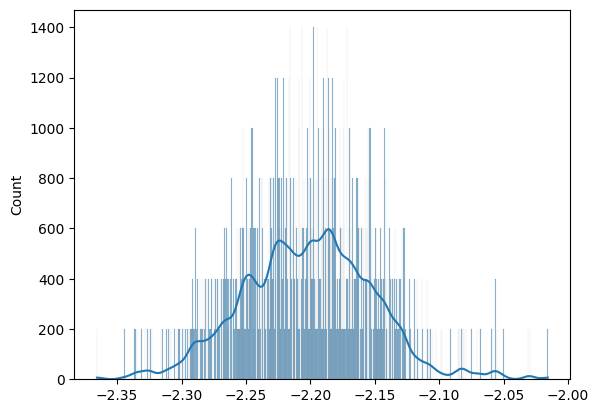

In [24]:
ax = sns.histplot(alpha_IMF_obs.flatten(), bins=1000, kde=True)
plt.show()

In [25]:
ax.lines[0].get_xdata()[np.argmax(ax.lines[0].get_ydata())]

np.float64(-2.1862745081360018)

In [26]:
model.multi_obs_sampler.data_t[0,:,:,0].shape

AttributeError: 'MultiObsSampler' object has no attribute 'data_t'

In [ ]:
test2 = model.multi_obs_sampler.data_t[1,:,:,0].cpu().T.detach().numpy()
test2

AttributeError: 'MultiObsSampler' object has no attribute 'data_t'

In [ ]:
test =model.multi_obs_sampler.data_t[0,:,:,0].cpu().T.detach().numpy()
test

array([[-1.3169137 , -2.329702  , -2.2958682 , ..., -2.2390125 ,
        -2.2312288 , -2.205108  ],
       [ 1.7533864 , -2.4378476 , -2.296626  , ..., -2.2493827 ,
        -2.2418501 , -2.2177567 ],
       [ 0.24047689, -2.3882387 , -2.290607  , ..., -2.2115483 ,
        -2.2007577 , -2.157668  ],
       ...,
       [ 2.7937202 , -2.4714403 , -2.2956247 , ..., -2.2547395 ,
        -2.248028  , -2.2284381 ],
       [ 1.7319338 , -2.4405534 , -2.292557  , ..., -2.2095516 ,
        -2.199     , -2.1576517 ],
       [ 0.58455724, -2.3971946 , -2.2956147 , ..., -2.2514102 ,
        -2.244868  , -2.2252507 ]], shape=(1000, 101), dtype=float32)

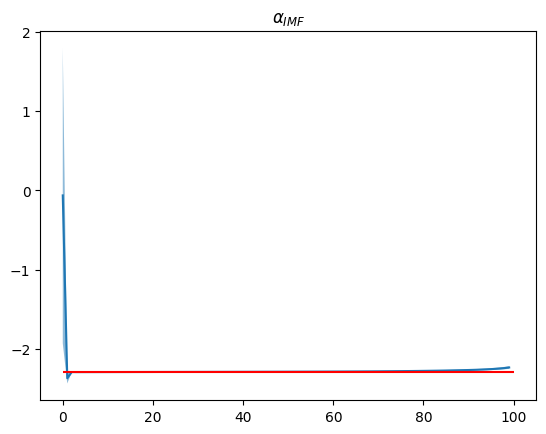

In [ ]:
x = np.arange(0,model.multi_obs_sampler.data_t[0,:,:,0].shape[0]-1)
y = model.multi_obs_sampler.data_t[0,:-1,:,0].detach().numpy().mean(axis=1)
yerr = model.multi_obs_sampler.data_t[0,:-1,:,0].detach().numpy().std(axis=1)

plt.plot(x,y)
plt.fill_between(x, y-yerr, y+yerr, alpha=0.5)
plt.hlines(-2.3, 0, model.multi_obs_sampler.data_t[0,:,:,0].shape[0]-1, color='red')
plt.title(r"$\alpha_{IMF}$")
plt.show()

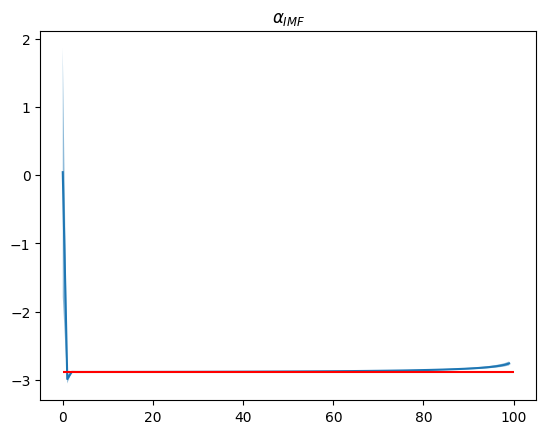

In [ ]:
x = np.arange(0,model.multi_obs_sampler.data_t[0,:,:,1].shape[0]-1)
y = model.multi_obs_sampler.data_t[0,:-1,:,1].detach().numpy().mean(axis=1)
yerr = model.multi_obs_sampler.data_t[0,:-1,:,1].detach().numpy().std(axis=1)

plt.plot(x,y)
plt.fill_between(x, y-yerr, y+yerr, alpha=0.5)
plt.hlines(-2.89, 0, model.multi_obs_sampler.data_t[0,:,:,1].shape[0]-1, color='red')
plt.title(r"$\alpha_{IMF}$")
plt.show()

In [ ]:
    def _compositional_score(self, scores, x, t, hierarchy):
        n_obs = scores.shape[0]

        mu_prior = torch.zeros_like(x)
        mu_prior[:,:,0] = -2.3
        mu_prior[:,:,1] = -2.89
        sigma_prior = torch.ones_like(x)
        sigma_prior[:,:,0] = 0.3
        sigma_prior[:,:,1] = 0.3

        # Diffused prior score: ∇log p_t(θ) for a Gaussian prior N(mu, sigma^2).
        # The VESDE forward process smears the prior to N(mu, sigma^2 + std(t)^2),
        # so the score must use the diffused variance, not sigma^2 alone.
        # Using sigma^2 alone causes |prior_score| >> 1 at early times (large t)
        # because x ~ O(std(t)) >> sigma_prior, leading to NaN.
        marginal_std = self.sde.marginal_prob_std(t)
        diffused_var = sigma_prior**2 + marginal_std**2
        prior_score = -(x - mu_prior) / diffused_var

        # F-NPSE score (Geffner et al. 2023, Eq. 7):
        #   s_composed = (1-n)(T-t)/T * ∇log p(θ) + Σ_j s(θ,t,x_j)
        # Normalised by n_obs so the step magnitude stays O(single-score),
        # keeping it compatible with the VESDE step size sigma^(2t)*score*dt
        # (which was calibrated for a single observation):
        #   → (1/n - 1)(1-t) * ∇log p_t(θ) + mean_j s(θ,t,x_j)
        prefactor = (1.0 / n_obs - 1.0) * (1.0 - t)
        mean_scores = torch.mean(scores, dim=0, keepdim=True).expand_as(scores)
        compositional_scores = prefactor * prior_score + mean_scores

        scores[:,:,hierarchy] = compositional_scores[:,:,hierarchy]

        return scores